<a href="https://colab.research.google.com/github/carlos-osorio/monitor-portuario/blob/main/notebooks/02_diseno_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Ajusta el nombre al snapshot más reciente que veas en data/ del repo
URL = ("https://raw.githubusercontent.com/carlos-osorio/monitor-portuario/"
       "main/data/portwatch_2026-07-09.csv")

df = pd.read_csv(URL, parse_dates=["date"])

# Serie semanal de importaciones por puerto (indicador principal)
sem = (df.set_index("date")
         .groupby("portname")["import"]
         .resample("W").sum()
         .unstack(level=0))          # → una columna por puerto

sem = sem.iloc[:-1]                  # excluir la última semana (parcial) — regla del contrato
print(sem.tail(3))

portname    Barranquilla  Buenaventura  Cartagena  Santa Marta
date                                                          
2026-06-14         97720        161054     272859        28594
2026-06-21        104744        340039     314589        80451
2026-06-28        160814        203561     350920       105708


Rango de factores estacionales por puerto:
     Barranquilla  Buenaventura  Cartagena  Santa Marta
min          0.41          0.68       0.74         0.44
max          1.67          1.32       1.32         1.89


<Axes: title={'center': 'Factor estacional por semana del año'}, xlabel='semana'>

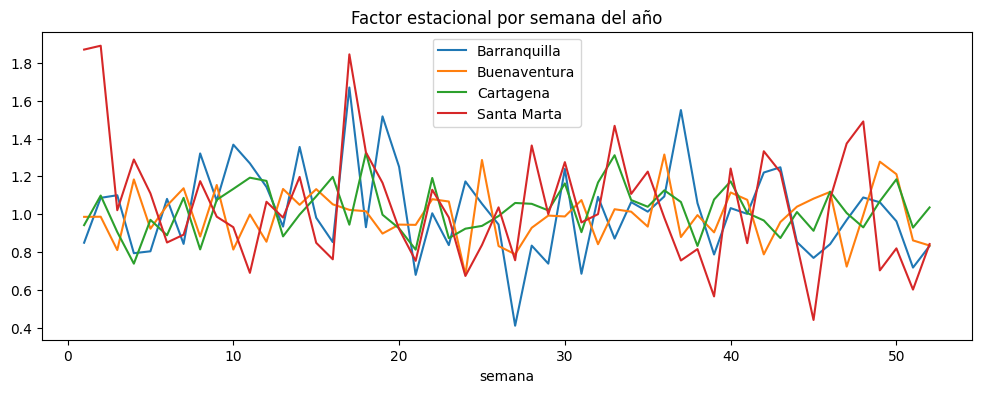

In [3]:
factores = {}

for puerto in sem.columns:
    s = sem[puerto].dropna().to_frame("valor")
    s["anio"] = s.index.year
    s["semana"] = s.index.isocalendar().week.astype(int)
    s = s[s["semana"] <= 52]                      # descarta la semana 53 (pocos años la tienen)

    nivel_anual = s.groupby("anio")["valor"].transform("median")
    s["ratio"] = s["valor"] / nivel_anual         # forma del año, sin tendencia

    factores[puerto] = s.groupby("semana")["ratio"].median()

tabla_factores = pd.DataFrame(factores)

print("Rango de factores estacionales por puerto:")
print(tabla_factores.agg(["min", "max"]).round(2))

tabla_factores.plot(figsize=(12, 4), title="Factor estacional por semana del año")

In [4]:
K = 13          # ventana: un trimestre
UMBRALES = [3.0, 3.5, 4.0]

def z_modificado(serie, k=K):
    """z robusto de cada semana contra la ventana de las k semanas ANTERIORES."""
    mediana_movil = serie.rolling(k).median().shift(1)          # solo pasado
    mad_movil = (serie.rolling(k)
                       .apply(lambda v: np.median(np.abs(v - np.median(v))), raw=True)
                       .shift(1))
    return 0.6745 * (serie - mediana_movil) / mad_movil

zs = sem.apply(z_modificado)

# Conteo de alertas históricas por umbral — solo CAÍDAS (z negativo), como acordamos
print("Alertas por año (total 4 puertos, ~7.5 años de historia):")
for T in UMBRALES:
    alertas = (zs <= -T)
    print(f"  |z| > {T}: {int(alertas.sum().sum())} alertas "
          f"→ {alertas.sum().sum() / 7.5:.1f} por año")

Alertas por año (total 4 puertos, ~7.5 años de historia):
  |z| > 3.0: 12 alertas → 1.6 por año
  |z| > 3.5: 9 alertas → 1.2 por año
  |z| > 4.0: 5 alertas → 0.7 por año


Proporción de semanas fuera de [0.9, 1.1]:
Barranquilla    0.62
Buenaventura    0.48
Cartagena       0.40
Santa Marta     0.75
dtype: float64

Factores en semanas de fiestas:
        Barranquilla  Buenaventura  Cartagena  Santa Marta
semana                                                    
1               0.85          0.99       0.94         1.87
2               1.09          0.99       1.10         1.89
51              0.72          0.86       0.93         0.60
52              0.83          0.83       1.04         0.84


<Axes: title={'center': 'Factores suavizados (mediana móvil de 5 semanas)'}, xlabel='semana'>

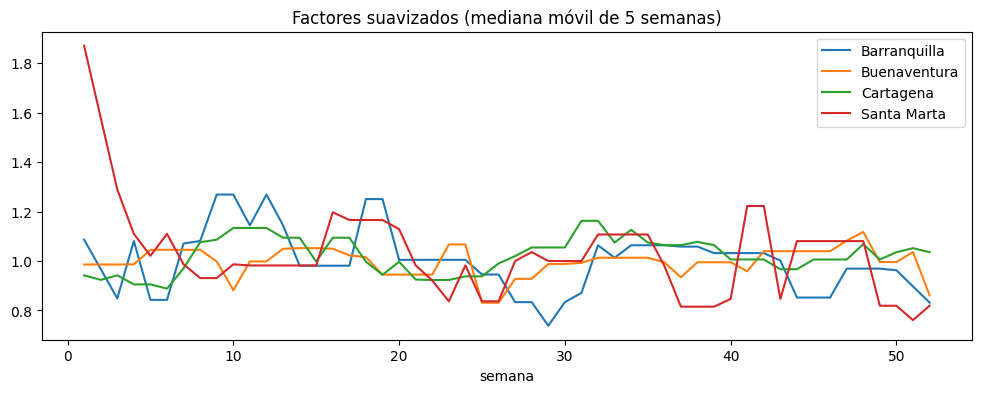

In [5]:
# ¿Qué fracción de semanas sale de la banda ±10%? (mejor resumen que min/max)
fuera = ((tabla_factores < 0.9) | (tabla_factores > 1.1)).mean().round(2)
print("Proporción de semanas fuera de [0.9, 1.1]:")
print(fuera)

# ¿Dónde viven los extremos? Si son las semanas 1-2 y 51-52, es efecto fiestas
print("\nFactores en semanas de fiestas:")
print(tabla_factores.loc[[1, 2, 51, 52]].round(2))

# ¿La curva es suave (estación) o dentada (ruido)? Suavizada para comparar
tabla_factores.rolling(5, center=True, min_periods=1).median().plot(
    figsize=(12, 4), title="Factores suavizados (mediana móvil de 5 semanas)")

In [6]:
# Las fechas: la prueba de sensibilidad y la de especificidad narrativa
T = 3.0
alertas = zs[zs <= -T].stack().sort_index()
for (fecha, puerto), z in alertas.items():
    print(f"{fecha.date()}  {puerto:<14} z = {z:5.1f}")

2019-05-05  Barranquilla   z =  -3.6
2019-07-21  Buenaventura   z =  -3.6
2020-02-16  Barranquilla   z =  -3.8
2022-05-08  Buenaventura   z =  -4.6
2022-05-22  Buenaventura   z =  -4.3
2022-05-29  Barranquilla   z =  -3.6
2022-11-06  Buenaventura   z =  -3.0
2023-05-14  Buenaventura   z =  -4.1
2025-09-14  Barranquilla   z =  -4.9
2025-10-05  Barranquilla   z =  -4.0
2025-10-19  Santa Marta    z =  -3.3
2025-11-09  Santa Marta    z =  -3.5


In [7]:
# ¿Qué dijo el detector durante el paro? (abril-julio 2021, Buenaventura)
print(zs.loc["2021-04-01":"2021-07-31", "Buenaventura"].round(2))

date
2021-04-04    4.07
2021-04-11   -0.67
2021-04-18    4.95
2021-04-25   -0.73
2021-05-02   -1.45
2021-05-09    0.40
2021-05-16   -0.33
2021-05-23   -1.15
2021-05-30   -2.38
2021-06-06   -0.95
2021-06-13   -2.52
2021-06-20    3.39
2021-06-27    1.63
2021-07-04   -0.73
2021-07-11   -0.50
2021-07-18   -0.14
2021-07-25    2.38
Freq: W-SUN, Name: Buenaventura, dtype: float64


In [8]:
# ¿Y durante la pandemia? (marzo-julio 2020, los cuatro puertos)
print(zs.loc["2020-03-01":"2020-07-31"].round(2))

portname    Barranquilla  Buenaventura  Cartagena  Santa Marta
date                                                          
2020-03-01          0.88          2.35       0.56         0.28
2020-03-08         -1.03         -1.44       1.60        -0.73
2020-03-15          3.49         -1.91       1.24        -0.76
2020-03-22          1.50         -0.98       0.31        -0.46
2020-03-29          1.41          1.13      -0.46        -1.36
2020-04-05          0.48         -0.28       0.97         1.25
2020-04-12          0.34          2.48      -0.12        -0.43
2020-04-19         -1.18         -0.44       0.08        -0.65
2020-04-26          0.85          1.36      -1.11         2.88
2020-05-03         -0.64         -0.06      -1.11         2.09
2020-05-10         -0.02          0.31      -1.74        -1.50
2020-05-17         -0.61          2.05      -0.81         0.05
2020-05-24         -0.61          0.01      -1.71        -0.12
2020-05-31         -0.30          1.27      -2.23      

In [9]:
def cusum_negativo(z, k=0.5):
    """Acumula desviaciones negativas: S_t = min(0, S_{t-1} + z_t + k)."""
    s, out = 0.0, []
    for val in z.fillna(0):
        s = min(0.0, s + val + k)
        out.append(s)
    return pd.Series(out, index=z.index)

cus = zs.apply(cusum_negativo)

# ¿Cuándo habría alertado, con umbral de decisión h?
for h in [4.0, 5.0, 6.0]:
    n = int((cus <= -h).sum().sum())
    print(f"h = {h}: {n} semanas-puerto en alerta → revisa fechas abajo")

h = 5.0
for (fecha, puerto) in cus[cus <= -h].stack().index:
    print(fecha.date(), puerto)

h = 4.0: 77 semanas-puerto en alerta → revisa fechas abajo
h = 5.0: 55 semanas-puerto en alerta → revisa fechas abajo
h = 6.0: 28 semanas-puerto en alerta → revisa fechas abajo
2019-07-28 Buenaventura
2019-08-04 Buenaventura
2019-08-11 Buenaventura
2019-08-25 Buenaventura
2020-02-16 Barranquilla
2020-02-23 Barranquilla
2020-03-01 Barranquilla
2020-03-08 Barranquilla
2020-05-31 Cartagena
2020-06-07 Cartagena
2020-06-14 Cartagena
2020-06-21 Cartagena
2020-06-28 Cartagena
2020-07-05 Cartagena
2020-07-12 Cartagena
2020-07-19 Cartagena
2021-06-13 Buenaventura
2021-07-11 Barranquilla
2021-07-18 Barranquilla
2021-07-25 Barranquilla
2021-08-01 Barranquilla
2021-08-08 Barranquilla
2022-06-05 Barranquilla
2022-06-12 Barranquilla
2022-06-19 Barranquilla
2022-06-26 Barranquilla
2022-07-03 Barranquilla
2022-07-10 Barranquilla
2022-07-17 Barranquilla
2022-07-24 Barranquilla
2022-07-31 Barranquilla
2022-08-07 Barranquilla
2022-08-14 Barranquilla
2022-08-21 Barranquilla
2022-08-28 Barranquilla
2022-09

In [10]:
def cusum_negativo(z, k=0.25):
    """Acumula desviaciones negativas: S_t = min(0, S_{t-1} + z_t + k)."""
    s, out = 0.0, []
    for val in z.fillna(0):
        s = min(0.0, s + val + k)
        out.append(s)
    return pd.Series(out, index=z.index)

cus = zs.apply(cusum_negativo)

# ¿Cuándo habría alertado, con umbral de decisión h?
for h in [4.0, 5.0, 6.0]:
    n = int((cus <= -h).sum().sum())
    print(f"h = {h}: {n} semanas-puerto en alerta → revisa fechas abajo")

h = 5.0
for (fecha, puerto) in cus[cus <= -h].stack().index:
    print(fecha.date(), puerto)

h = 4.0: 200 semanas-puerto en alerta → revisa fechas abajo
h = 5.0: 136 semanas-puerto en alerta → revisa fechas abajo
h = 6.0: 94 semanas-puerto en alerta → revisa fechas abajo
2019-07-28 Buenaventura
2019-08-04 Buenaventura
2019-08-11 Buenaventura
2019-08-18 Buenaventura
2019-08-25 Buenaventura
2019-09-01 Buenaventura
2019-09-08 Buenaventura
2019-09-15 Buenaventura
2020-01-19 Buenaventura
2020-01-26 Buenaventura
2020-02-02 Buenaventura
2020-02-09 Buenaventura
2020-02-16 Barranquilla
2020-02-23 Barranquilla
2020-03-01 Barranquilla
2020-03-08 Barranquilla
2020-03-22 Buenaventura
2020-05-24 Cartagena
2020-05-31 Cartagena
2020-06-07 Cartagena
2020-06-14 Cartagena
2020-06-21 Cartagena
2020-06-28 Cartagena
2020-07-05 Cartagena
2020-07-12 Cartagena
2020-07-19 Buenaventura
2020-07-19 Cartagena
2020-07-26 Buenaventura
2020-07-26 Cartagena
2020-08-02 Buenaventura
2020-08-02 Cartagena
2020-08-09 Buenaventura
2020-08-16 Buenaventura
2020-08-23 Buenaventura
2020-08-30 Buenaventura
2021-02-14 Bar